In [ ]:
import tensorflow as tf
print("GPU:", tf.config.list_physical_devices('GPU'))

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os

print("Files in current directory:")
print(os.listdir())

Files in current directory:
['.config', 'archive (1).zip', 'sample_data']


In [ ]:
!unzip "archive (1).zip" -d dataset

Streaming output truncated to the last 5000 lines.
  inflating: dataset/DeepPCB/PCBData/group12100/12100/12100156_test.jpg  
  inflating: dataset/DeepPCB/PCBData/group12100/12100/12100157_temp.jpg  
  inflating: dataset/DeepPCB/PCBData/group12100/12100/12100157_test.jpg  
  inflating: dataset/DeepPCB/PCBData/group12100/12100/12100158_temp.jpg  
  inflating: dataset/DeepPCB/PCBData/group12100/12100/12100158_test.jpg  
  inflating: dataset/DeepPCB/PCBData/group12100/12100/12100159_temp.jpg  
  inflating: dataset/DeepPCB/PCBData/group12100/12100/12100159_test.jpg  
  inflating: dataset/DeepPCB/PCBData/group12100/12100/12100160_temp.jpg  
  inflating: dataset/DeepPCB/PCBData/group12100/12100/12100160_test.jpg  
  inflating: dataset/DeepPCB/PCBData/group12100/12100/12100161_temp.jpg  
  inflating: dataset/DeepPCB/PCBData/group12100/12100/12100161_test.jpg  
  inflating: dataset/DeepPCB/PCBData/group12100/12100/12100162_temp.jpg  
  inflating: dataset/DeepPCB/PCBData/group12100/12100/1210016

In [ ]:
!ls dataset

Bridge_Crack_Image  CrackForest  DeepPCB  Magnetic-Tile-Defect


In [ ]:
!ls dataset/Magnetic-Tile-Defect

MT_Blowhole  MT_Break  MT_Crack  MT_Fray  MT_Free


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 128   # safe for Colab
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    brightness_range=[0.8,1.2],
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    "binary_dataset/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    "binary_dataset/val",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 690 images belonging to 2 classes.
Found 173 images belonging to 2 classes.


In [ ]:
from tensorflow.keras import layers, models

model_scratch = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model_scratch.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_scratch.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_scratch = model_scratch.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 12s 184ms/step - accuracy: 0.6467 - loss: 0.5948 - val_accuracy: 0.8728 - val_loss: 0.3694
Epoch 2/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 14s 109ms/step - accuracy: 0.7992 - loss: 0.3948 - val_accuracy: 0.9017 - val_loss: 0.2384
Epoch 3/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - accuracy: 0.8236 - loss: 0.3730 - val_accuracy: 0.9249 - val_loss: 0.1997
Epoch 4/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - accuracy: 0.8695 - loss: 0.2979 - val_accuracy: 0.9191 - val_loss: 0.2030
Epoch 5/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step - accuracy: 0.8598 - loss: 0.3127 - val_accuracy: 0.9075 - val_loss: 0.2466


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    input_shape=(128,128,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model_transfer = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model_transfer.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_transfer = model_transfer.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 25s 374ms/step - accuracy: 0.6994 - loss: 0.6146 - val_accuracy: 0.9075 - val_loss: 0.2512
Epoch 2/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - accuracy: 0.8538 - loss: 0.3333 - val_accuracy: 0.8960 - val_loss: 0.2886
Epoch 3/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - accuracy: 0.8509 - loss: 0.3634 - val_accuracy: 0.9191 - val_loss: 0.2523
Epoch 4/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.8779 - loss: 0.3082 - val_accuracy: 0.9075 - val_loss: 0.2811
Epoch 5/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.8867 - loss: 0.2777 - val_accuracy: 0.9017 - val_loss: 0.2472


In [ ]:
import zipfile

with zipfile.ZipFile("archive (1).zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Extraction Completed ✅")

Extraction Completed ✅


In [ ]:
import os
print(os.listdir("dataset"))

['DeepPCB', 'Magnetic-Tile-Defect']


In [ ]:
import os
import shutil
import random

source_dir = "dataset/Magnetic-Tile-Defect"
target_dir = "binary_dataset"

# Create folders
os.makedirs(f"{target_dir}/train/Pass", exist_ok=True)
os.makedirs(f"{target_dir}/train/Defect", exist_ok=True)
os.makedirs(f"{target_dir}/val/Pass", exist_ok=True)
os.makedirs(f"{target_dir}/val/Defect", exist_ok=True)

for class_name in os.listdir(source_dir):
    class_path = os.path.join(source_dir, class_name, "Imgs")

    if not os.path.exists(class_path):
        continue

    images = os.listdir(class_path)
    random.shuffle(images)
    split = int(0.8 * len(images))

    for img in images[:split]:
        if class_name == "MT_Free":
            shutil.copy(os.path.join(class_path, img),
                        f"{target_dir}/train/Pass/")
        else:
            shutil.copy(os.path.join(class_path, img),
                        f"{target_dir}/train/Defect/")

    for img in images[split:]:
        if class_name == "MT_Free":
            shutil.copy(os.path.join(class_path, img),
                        f"{target_dir}/val/Pass/")
        else:
            shutil.copy(os.path.join(class_path, img),
                        f"{target_dir}/val/Defect/")

print("Binary dataset created successfully ✅")

Binary dataset created successfully ✅


In [ ]:
print(os.listdir("binary_dataset"))
print(os.listdir("binary_dataset/train"))
print(os.listdir("binary_dataset/val"))

['train', 'val']
['Defect', 'Pass']
['Defect', 'Pass']


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 128
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    brightness_range=[0.8,1.2],
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    "binary_dataset/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    "binary_dataset/val",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 690 images belonging to 2 classes.
Found 173 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    input_shape=(128,128,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model_transfer = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model_transfer.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_transfer.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history_transfer = model_transfer.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 51s 727ms/step - accuracy: 0.7537 - loss: 0.5164 - val_accuracy: 0.8844 - val_loss: 0.2833
Epoch 2/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - accuracy: 0.8752 - loss: 0.3157 - val_accuracy: 0.8902 - val_loss: 0.2615
Epoch 3/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.8738 - loss: 0.2945 - val_accuracy: 0.9191 - val_loss: 0.2122
Epoch 4/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.8548 - loss: 0.3210 - val_accuracy: 0.9075 - val_loss: 0.2150
Epoch 5/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step - accuracy: 0.8924 - loss: 0.2791 - val_accuracy: 0.8902 - val_loss: 0.2508


In [ ]:
model_transfer.save("mobilenet_model.h5")

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

val_generator.reset()

pred_probs = model_transfer.predict(val_generator)
predictions = (pred_probs > 0.5).astype(int).flatten()

true_labels = val_generator.classes

print("Confusion Matrix:")
print(confusion_matrix(true_labels, predictions))

print("\nClassification Report:")
print(classification_report(true_labels, predictions, target_names=["Defect", "Pass"]))

11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 441ms/step
Confusion Matrix:
[[100  16]
 [  3  54]]

Classification Report:
              precision    recall  f1-score   support

      Defect       0.97      0.86      0.91       116
        Pass       0.77      0.95      0.85        57

    accuracy                           0.89       173
   macro avg       0.87      0.90      0.88       173
weighted avg       0.91      0.89      0.89       173



In [ ]:
base_model.trainable = True

for layer in base_model.layers[:100]:
    layer.trainable = False

In [ ]:
from tensorflow.keras.optimizers import Adam

model_transfer.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_finetune = model_transfer.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 45s 510ms/step - accuracy: 0.6725 - loss: 3.6851 - val_accuracy: 0.8150 - val_loss: 0.4123
Epoch 2/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - accuracy: 0.6523 - loss: 3.0125 - val_accuracy: 0.7399 - val_loss: 0.5326
Epoch 3/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - accuracy: 0.6977 - loss: 1.8736 - val_accuracy: 0.6879 - val_loss: 0.6866
Epoch 4/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 123ms/step - accuracy: 0.7283 - loss: 1.0839 - val_accuracy: 0.6705 - val_loss: 0.7942
Epoch 5/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - accuracy: 0.7711 - loss: 0.6405 - val_accuracy: 0.6647 - val_loss: 0.8429


In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    base_model = model.layers[0]  # MobileNetV2 inside Sequential

    grad_model = Model(
        inputs=model.input,
        outputs=[base_model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [ ]:
import os
print(os.listdir("binary_dataset/val/Defect")[:5])

['exp1_num_20362.jpg', 'exp4_num_322656.png', 'exp4_num_62606.png', 'exp5_num_62619.jpg', 'exp3_num_271400.jpg']


In [ ]:
import tensorflow as tf
import numpy as np

img_path = "binary_dataset/val/Defect/exp1_num_20362.jpg"

img = tf.keras.preprocessing.image.load_img(img_path, target_size=(128,128))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

print("Image Loaded Successfully ✅")

Image Loaded Successfully ✅


In [ ]:
for layer in model_transfer.layers[0].layers:
    print(layer.name)

input_layer
Conv1
bn_Conv1
Conv1_relu
expanded_conv_depthwise
expanded_conv_depthwise_BN
expanded_conv_depthwise_relu
expanded_conv_project
expanded_conv_project_BN
block_1_expand
block_1_expand_BN
block_1_expand_relu
block_1_pad
block_1_depthwise
block_1_depthwise_BN
block_1_depthwise_relu
block_1_project
block_1_project_BN
block_2_expand
block_2_expand_BN
block_2_expand_relu
block_2_depthwise
block_2_depthwise_BN
block_2_depthwise_relu
block_2_project
block_2_project_BN
block_2_add
block_3_expand
block_3_expand_BN
block_3_expand_relu
block_3_pad
block_3_depthwise
block_3_depthwise_BN
block_3_depthwise_relu
block_3_project
block_3_project_BN
block_4_expand
block_4_expand_BN
block_4_expand_relu
block_4_depthwise
block_4_depthwise_BN
block_4_depthwise_relu
block_4_project
block_4_project_BN
block_4_add
block_5_expand
block_5_expand_BN
block_5_expand_relu
block_5_depthwise
block_5_depthwise_BN
block_5_depthwise_relu
block_5_project
block_5_project_BN
block_5_add
block_6_expand
block_6_ex

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    input_shape=(128,128,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

# Functional API
inputs = base_model.input
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model_transfer = Model(inputs=inputs, outputs=outputs)

model_transfer.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_transfer.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history_transfer = model_transfer.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 30s 455ms/step - accuracy: 0.8093 - loss: 0.4260 - val_accuracy: 0.8671 - val_loss: 0.2970
Epoch 2/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.8766 - loss: 0.3066 - val_accuracy: 0.8844 - val_loss: 0.3181
Epoch 3/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - accuracy: 0.8558 - loss: 0.3243 - val_accuracy: 0.9133 - val_loss: 0.1981
Epoch 4/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 7s 171ms/step - accuracy: 0.8903 - loss: 0.2684 - val_accuracy: 0.8844 - val_loss: 0.2362
Epoch 5/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - accuracy: 0.8597 - loss: 0.3124 - val_accuracy: 0.8613 - val_loss: 0.2484


In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Model

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()

In [ ]:
heatmap = make_gradcam_heatmap(img_array, model_transfer, "Conv_1")

In [ ]:
model_transfer.build((None, 224, 224, 3))

In [ ]:
heatmap = make_gradcam_heatmap(img_array, model_transfer, "Conv_1")

In [ ]:
for layer in model_transfer.layers:
    print(layer.name)

input_layer_2
Conv1
bn_Conv1
Conv1_relu
expanded_conv_depthwise
expanded_conv_depthwise_BN
expanded_conv_depthwise_relu
expanded_conv_project
expanded_conv_project_BN
block_1_expand
block_1_expand_BN
block_1_expand_relu
block_1_pad
block_1_depthwise
block_1_depthwise_BN
block_1_depthwise_relu
block_1_project
block_1_project_BN
block_2_expand
block_2_expand_BN
block_2_expand_relu
block_2_depthwise
block_2_depthwise_BN
block_2_depthwise_relu
block_2_project
block_2_project_BN
block_2_add
block_3_expand
block_3_expand_BN
block_3_expand_relu
block_3_pad
block_3_depthwise
block_3_depthwise_BN
block_3_depthwise_relu
block_3_project
block_3_project_BN
block_4_expand
block_4_expand_BN
block_4_expand_relu
block_4_depthwise
block_4_depthwise_BN
block_4_depthwise_relu
block_4_project
block_4_project_BN
block_4_add
block_5_expand
block_5_expand_BN
block_5_expand_relu
block_5_depthwise
block_5_depthwise_BN
block_5_depthwise_relu
block_5_project
block_5_project_BN
block_5_add
block_6_expand
block_6_

In [ ]:
print(model_transfer.input_shape)

(None, 128, 128, 3)


In [ ]:
_ = model_transfer(tf.zeros((1, 128, 128, 3)))

In [ ]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

img = load_img(img_path, target_size=(128, 128))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

print(img_array.shape)

(1, 128, 128, 3)


In [ ]:
heatmap = make_gradcam_heatmap(
    img_array,
    model_transfer,
    "Conv_1"
)

print("Heatmap Generated ✅")

Heatmap Generated ✅


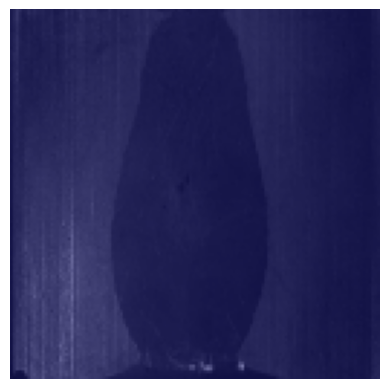

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

# Resize heatmap
heatmap = cv2.resize(heatmap, (128, 128))

# Convert to 0-255
heatmap = np.uint8(255 * heatmap)

# Apply colormap
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# Load original image
img = cv2.imread(img_path)
img = cv2.resize(img, (128, 128))

# Superimpose heatmap
superimposed_img = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [ ]:
!pip freeze > requirements.txt

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 128
BATCH_SIZE = 16

def get_train_val_generators(train_dir, val_dir):

    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        zoom_range=0.2,
        brightness_range=[0.8, 1.2],
        horizontal_flip=True
    )

    val_datagen = ImageDataGenerator(rescale=1./255)

    train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='binary'
    )

    val_generator = val_datagen.flow_from_directory(
        val_dir,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='binary'
    )

    return train_generator, val_generator

In [ ]:
%%writefile data_preprocessing.py

from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 128
BATCH_SIZE = 16

def get_train_val_generators(train_dir, val_dir):

    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        zoom_range=0.2,
        brightness_range=[0.8, 1.2],
        horizontal_flip=True
    )

    val_datagen = ImageDataGenerator(rescale=1./255)

    train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='binary'
    )

    val_generator = val_datagen.flow_from_directory(
        val_dir,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='binary'
    )

    return train_generator, val_generator

Writing data_preprocessing.py


In [ ]:
%%writefile model_training.py

import tensorflow as tf
from tensorflow.keras import layers, models

def build_model(input_shape=(128, 128, 3)):

    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


def train_model(model, train_generator, val_generator, epochs=10):

    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=epochs
    )

    return history

Writing model_training.py


In [ ]:
%%writefile utils.py

import matplotlib.pyplot as plt

def plot_training_history(history, save_path=None):

    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(len(acc))

    plt.figure(figsize=(12, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc)
    plt.plot(epochs, val_acc)
    plt.title('Training and Validation Accuracy')
    plt.legend(['Train Accuracy', 'Validation Accuracy'])

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss)
    plt.plot(epochs, val_loss)
    plt.title('Training and Validation Loss')
    plt.legend(['Train Loss', 'Validation Loss'])

    if save_path:
        plt.savefig(save_path)

    plt.show()

Writing utils.py


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [ ]:
!ls /content

data_preprocessing.py  requirements.txt  utils.py
model_training.py      sample_data


In [ ]:
!unzip "archive (1).zip"

Archive:  archive (1).zip
  inflating: Magnetic-Tile-Defect/MT_Blowhole/Imgs/exp1_num_108719.jpg  
  inflating: Magnetic-Tile-Defect/MT_Blowhole/Imgs/exp1_num_108719.png  
  inflating: Magnetic-Tile-Defect/MT_Blowhole/Imgs/exp1_num_108889.jpg  
  inflating: Magnetic-Tile-Defect/MT_Blowhole/Imgs/exp1_num_108889.png  
  inflating: Magnetic-Tile-Defect/MT_Blowhole/Imgs/exp1_num_262480.jpg  
  inflating: Magnetic-Tile-Defect/MT_Blowhole/Imgs/exp1_num_262480.png  
  inflating: Magnetic-Tile-Defect/MT_Blowhole/Imgs/exp1_num_265077.jpg  
  inflating: Magnetic-Tile-Defect/MT_Blowhole/Imgs/exp1_num_265077.png  
  inflating: Magnetic-Tile-Defect/MT_Blowhole/Imgs/exp1_num_290998.jpg  
  inflating: Magnetic-Tile-Defect/MT_Blowhole/Imgs/exp1_num_290998.png  
  inflating: Magnetic-Tile-Defect/MT_Blowhole/Imgs/exp1_num_297464.jpg  
  inflating: Magnetic-Tile-Defect/MT_Blowhole/Imgs/exp1_num_297464.png  
  inflating: Magnetic-Tile-Defect/MT_Blowhole/Imgs/exp1_num_308015.jpg  
  inflating: Magnetic-Til

In [ ]:
!ls

'archive (1).zip'	 Magnetic-Tile-Defect   requirements.txt   utils.py
 data_preprocessing.py	 model_training.py      sample_data


In [ ]:
!ls Magnetic-Tile-Defect

MT_Blowhole  MT_Break  MT_Crack  MT_Fray  MT_Free


In [ ]:
import os
import shutil
import random

source_dir = "/content/Magnetic-Tile-Defect"
base_dir = "/content/dataset"

train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")

# Create folders
for folder in ["train/Defect", "train/Normal", "val/Defect", "val/Normal"]:
    os.makedirs(os.path.join(base_dir, folder), exist_ok=True)

# Loop through original dataset
for class_name in os.listdir(source_dir):

    class_path = os.path.join(source_dir, class_name, "Imgs")

    if not os.path.isdir(class_path):
        continue

    images = os.listdir(class_path)
    random.shuffle(images)

    split = int(0.8 * len(images))
    train_images = images[:split]
    val_images = images[split:]

    # Decide label
    if class_name == "MT_Free":
        label = "Normal"
    else:
        label = "Defect"

    # Copy train images
    for img in train_images:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(train_dir, label, img)
        )

    # Copy validation images
    for img in val_images:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(val_dir, label, img)
        )

print("Dataset split completed successfully.")

Dataset split completed successfully.


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    "/content/dataset/train",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    "/content/dataset/val",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

Found 690 images belonging to 2 classes.
Found 173 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 386ms/step - accuracy: 0.6531 - loss: 0.6887 - val_accuracy: 0.8208 - val_loss: 0.4044
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - accuracy: 0.8500 - loss: 0.3521 - val_accuracy: 0.8208 - val_loss: 0.3676
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.8594 - loss: 0.3604 - val_accuracy: 0.8324 - val_loss: 0.3324
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.8991 - loss: 0.3010 - val_accuracy: 0.8844 - val_loss: 0.3055
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.9354 - loss: 0.2419 - val_accuracy: 0.8150 - val_loss: 0.3677
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.8662 - loss: 0.3217 - val_accuracy: 0.8555 - val_loss: 0.2969
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.8979 - loss: 0.2551 - val_accuracy: 0.8613 - val_loss: 0.2663
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.9217 - loss: 0.2203 - val_accuracy: 0.8671 

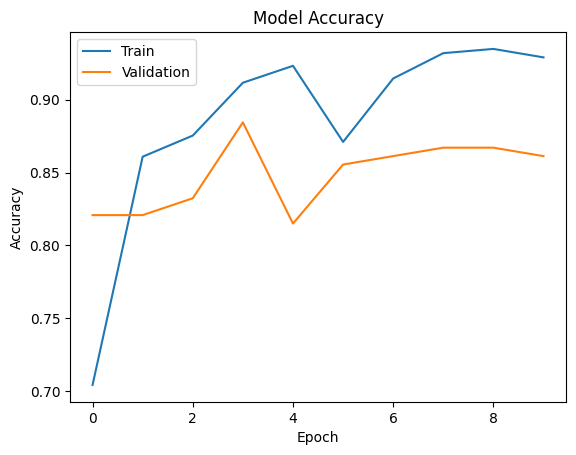

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

In [ ]:
from tensorflow.keras.layers import GlobalAveragePooling2D

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Load base model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base model
base_model.trainable = False

# Build model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.3425 - loss: 1.0119 - val_accuracy: 0.4682 - val_loss: 0.7441
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.5537 - loss: 0.6645 - val_accuracy: 0.7861 - val_loss: 0.5700
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - accuracy: 0.8356 - loss: 0.5307 - val_accuracy: 0.8382 - val_loss: 0.5156
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.8517 - loss: 0.4783 - val_accuracy: 0.6936 - val_loss: 0.4950
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.7747 - loss: 0.4716 - val_accuracy: 0.8382 - val_loss: 0.4816
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.8547 - loss: 0.4624 - val_accuracy: 0.8382 - val_loss: 0.4697
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.8588 - loss: 0.4500 - val_accuracy: 0.8208 - val_loss: 0.4590
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.8707 - loss: 0.4158 - val_accuracy: 0.8208 - v

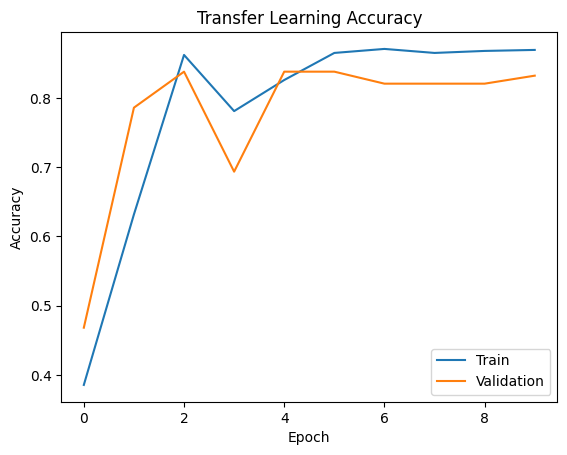

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Transfer Learning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

In [ ]:
# Unfreeze top layers
base_model.trainable = True

# Freeze first 100 layers (keep early features stable)
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 44s 917ms/step - accuracy: 0.6834 - loss: 0.7672 - val_accuracy: 0.8208 - val_loss: 0.4613
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.8151 - loss: 0.4252 - val_accuracy: 0.7630 - val_loss: 0.4940
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.8590 - loss: 0.2990 - val_accuracy: 0.6994 - val_loss: 0.5384
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.9421 - loss: 0.2001 - val_accuracy: 0.6301 - val_loss: 0.5953
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.9646 - loss: 0.1576 - val_accuracy: 0.6012 - val_loss: 0.6593


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    "/content/dataset/train",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    "/content/dataset/val",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

Found 690 images belonging to 2 classes.
Found 173 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    GlobalAveragePooling2D(),

    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,569 (396.75 KB)

 Trainable params: 101,569 (396.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15
)

Epoch 1/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 549ms/step - accuracy: 0.6613 - loss: 0.6277 - val_accuracy: 0.6705 - val_loss: 0.5896
Epoch 2/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 438ms/step - accuracy: 0.6590 - loss: 0.6020 - val_accuracy: 0.6705 - val_loss: 0.5807
Epoch 3/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 387ms/step - accuracy: 0.6702 - loss: 0.5752 - val_accuracy: 0.6705 - val_loss: 0.5645
Epoch 4/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 394ms/step - accuracy: 0.6488 - loss: 0.5452 - val_accuracy: 0.6705 - val_loss: 0.4765
Epoch 5/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 430ms/step - accuracy: 0.6743 - loss: 0.4914 - val_accuracy: 0.6821 - val_loss: 0.4208
Epoch 6/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 428ms/step - accuracy: 0.7725 - loss: 0.4102 - val_accuracy: 0.7225 - val_loss: 0.4006
Epoch 7/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 369ms/step - accuracy: 0.8149 - loss: 0.3974 - val_accuracy: 0.8497 - val_loss: 0.3713
Epoch 8/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 409ms/step - accuracy: 0.8591 - loss: 0.3361 - val_accuracy: 

In [ ]:
model.save("magnetic_tile_defect_model.h5")

In [ ]:
plt.savefig("accuracy_graph.png")

<Figure size 640x480 with 0 Axes>

In [ ]:
from google.colab import files

In [ ]:
files.download("accuracy_graph.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

In [ ]:
import tensorflow as tf
import random

seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [ ]:
val_loss, val_acc = model.evaluate(val_generator)
print("Final Validation Accuracy:", val_acc)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.8812 - loss: 0.2714
Final Validation Accuracy: 0.8670520186424255


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

val_datagen = ImageDataGenerator(rescale=1./255)

validation_generator = val_datagen.flow_from_directory(
    'dataset/val',      # ⚠ change this to your validation folder path
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 173 images belonging to 2 classes.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
import os
os.listdir()

['.config',
 'Magnetic-Tile-Defect',
 'dataset',
 'archive (1).zip',
 'utils.py',
 'requirements.txt',
 'magnetic_tile_defect_model.h5',
 'data_preprocessing.py',
 'model_training.py',
 'accuracy_graph.png',
 'sample_data']

In [ ]:
!ls dataset

train  val


In [ ]:
datagen = ImageDataGenerator(rescale=1./255)

validation_generator = datagen.flow_from_directory(
    'dataset/val',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 173 images belonging to 2 classes.


In [ ]:
y_true = validation_generator.classes

y_pred_probs = model.predict(validation_generator)
y_pred = y_pred_probs.argmax(axis=1)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 186ms/step


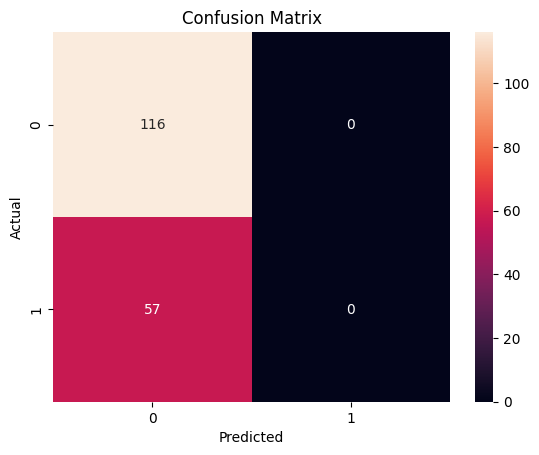

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
plt.savefig("confusion_matrix.png")

<Figure size 640x480 with 0 Axes>

In [ ]:
print(classification_report(
    y_true,
    y_pred,
    target_names=validation_generator.class_indices.keys()
))

              precision    recall  f1-score   support

      Defect       0.67      1.00      0.80       116
      Normal       0.00      0.00      0.00        57

    accuracy                           0.67       173
   macro avg       0.34      0.50      0.40       173
weighted avg       0.45      0.67      0.54       173



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
